In [1]:
# ============================================================
# NOTEBOOK 1: EDA
# ============================================================

# -------------------- Cell 1 --------------------

import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (10, 5)

BASE_DIR = Path(r"D:\iit\DSGP\NutriScanner\health-risk-recommendations\research\NoteBooks")
DATA_DIR = BASE_DIR / "data"
PLOT_DIR = BASE_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)

DATA_FILE = DATA_DIR / "health_nutrition_disease_dataset_12000.xlsx"

DISEASE_COLUMNS = [
    "Diabetes_Risk",
    "Hypertension_Risk",
    "Heart_Disease_Risk",
    "Obesity_Risk",
    "Anemia_Risk",
    "Kidney_Disease_Risk"
]

FEATURES = [
    "Age", "Gender", "BMI",
    "Daily_Calories_kcal",
    "Carbohydrates_g",
    "Protein_g",
    "Total_Fat_g",
    "Saturated_Fat_g",
    "Trans_Fat_g",
    "Total_Sugar_g",
    "Added_Sugar_g",
    "Fiber_g",
    "Sodium_mg",
    "Potassium_mg",
    "Calcium_mg",
    "Iron_mg",
    "Vitamin_D_IU",
    "Vitamin_B12_mcg",
    "Physical_Activity_min",
    "Water_Intake_L"
]

print("Base folder:", BASE_DIR)
print("Dataset path:", DATA_FILE)
print("File exists:", DATA_FILE.exists())

Base folder: D:\iit\DSGP\NutriScanner\health-risk-recommendations\research\NoteBooks
Dataset path: D:\iit\DSGP\NutriScanner\health-risk-recommendations\research\NoteBooks\data\health_nutrition_disease_dataset_12000.xlsx
File exists: False


In [2]:
# -------------------- Cell 2: Data Loading & Info --------------------
df = pd.read_excel(DATA_FILE)

print(f"Dataset Shape: {df.shape}")
print("\n--- Missing Values ---")
print(df[FEATURES + DISEASE_COLUMNS].isnull().sum())

print("\n--- Statistical Summary ---")
display(df[FEATURES].describe().T)

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\iit\\DSGP\\NutriScanner\\health-risk-recommendations\\research\\NoteBooks\\data\\health_nutrition_disease_dataset_12000.xlsx'

NameError: name 'df' is not defined

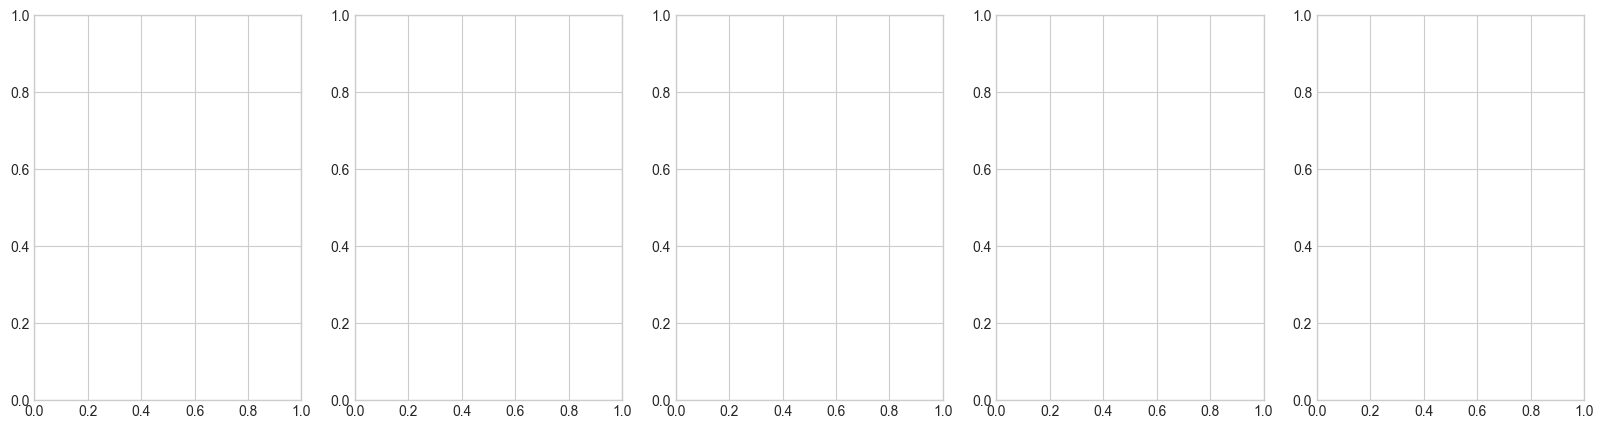

In [6]:
# -------------------- Cell 3: Distribution of Key Nutrients --------------------
cols_to_plot = ["Daily_Calories_kcal", "BMI", "Total_Sugar_g", "Sodium_mg", "Fiber_g"]

fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(20, 5))
for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Dist of {col}")

plt.tight_layout()
plt.savefig(PLOT_DIR / "nutrient_distributions.png")
plt.show()

In [40]:
# -------------------- Cell 4: Feature-Target Correlation --------------------
# We calculate correlation between nutrients and disease risks
corr_matrix = df[FEATURES + DISEASE_COLUMNS].corr()

plt.figure(figsize=(15, 10))
# Focusing only on how features affect the Risk columns
sns.heatmap(corr_matrix.loc[FEATURES, DISEASE_COLUMNS], annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Nutrient Correlation with Disease Risks")
plt.savefig(PLOT_DIR / "correlation_heatmap.png")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\iit\\DSGP\\NutriScanner\\health-risk-recommendations\\research\\NoteBooks\\data\\health_nutrition_disease_dataset_12000.xlsx'

In [ ]:
# -------------------- Cell 5: Disease Risk Prevalence --------------------
risk_counts = df[DISEASE_COLUMNS].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=risk_counts.values, y=risk_counts.index, palette="viridis")
plt.title("Prevalence of Disease Risks in Dataset")
plt.xlabel("Number of Cases")
plt.show()

In [ ]:
# -------------------- Cell 4 --------------------

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

df["Gender"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "salmon"])
axes[0].set_title("Gender Distribution")
axes[0].tick_params(axis="x", rotation=0)

for i, disease in enumerate(DISEASE_COLUMNS, start=1):
    df[disease].value_counts().plot(kind="bar", ax=axes[i], color=["mediumseagreen", "tomato"])
    axes[i].set_title(disease.replace("_", " "))
    axes[i].tick_params(axis="x", rotation=0)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# -------------------- Cell 5 --------------------

important_cols = [
    "Age", "BMI", "Daily_Calories_kcal",
    "Added_Sugar_g", "Fiber_g", "Sodium_mg",
    "Physical_Activity_min", "Water_Intake_L"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(important_cols):
    temp = pd.to_numeric(df[col], errors="coerce")
    sns.histplot(temp, kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(col.replace("_", " "))

plt.tight_layout()
plt.show()

In [38]:
# -------------------- Cell 6 --------------------

eda_df = df.copy()

eda_df["Gender"] = eda_df["Gender"].astype(str).str.strip().str.lower()
eda_df["Gender"] = eda_df["Gender"].map({"male": 0, "female": 1})

for disease in DISEASE_COLUMNS:
    eda_df[disease] = eda_df[disease].astype(str).str.strip().str.lower()
    eda_df[disease] = eda_df[disease].replace({
        "low": 0, "low risk": 0, "0": 0,
        "high": 1, "high risk": 1, "1": 1
    })

for col in FEATURES:
    if col != "Gender":
        eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")

corr_cols = [
    "Age", "Gender", "BMI", "Daily_Calories_kcal",
    "Added_Sugar_g", "Fiber_g", "Sodium_mg",
    "Physical_Activity_min", "Water_Intake_L"
] + DISEASE_COLUMNS

corr_matrix = eda_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

NameError: name 'FEATURES' is not defined